In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


# - 한셀안의 인쇄동작을 모두 수행
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# - matplotlib 초기 설정(한글 폰트 설정)
font_name = mpl.font_manager.FontProperties(fname='C:/Windows/Fonts/malgun.ttf').get_name()
mpl.rc('font', family=font_name)
mpl.rc('font',size=16) # 전체 폰트 지정

### 📚 타이타닉 데이터 결측치 처리 및 분석

#### 1️⃣ 'data/titanic.csv' 파일 읽어와 기본 정보 파악 
- 컬럼별 타입과 결측치를 파악하라

In [2]:
import pandas as pd

df = pd.read_csv('data/titanic.csv')
df.head()
df.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### 2️⃣ 결측치 상세 분석
- 컬럼별 결측치 개수와 비율을 확인하고 시각화로 파악하라

In [3]:
# 컬럼별 결측치 개수와 비율을 확인

sr = df.isna().sum()
sr2 = sr / len(df)
print(sr2)
sr2.apply('{:.1%}'.format)

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64


PassengerId     0.0%
Survived        0.0%
Pclass          0.0%
Name            0.0%
Sex             0.0%
Age            19.9%
SibSp           0.0%
Parch           0.0%
Ticket          0.0%
Fare            0.0%
Cabin          77.1%
Embarked        0.2%
dtype: object

Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64


<Axes: >

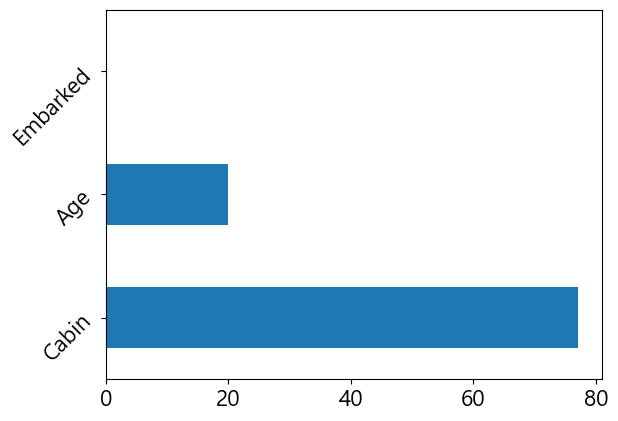

In [4]:
# 결측치가 있는 컬럼만 추출하여 시각화

sr = df.isna().sum().sort_values(ascending=False)
sr2 = sr[sr>0] / len(df) * 100
print(sr2)
sr2.plot(kind='barh', rot=45)


### 3️⃣ 결측치 처리 전략 1
1. Cabin 컬럼은 결측치가 너무 많아 무의한 컬럼이므로 삭제한다
2. Embarked 컬럼은 최빈값으로 채운다
3. Age컬럼은 객실 등급별 성별 그룹의 중앙값 나이로 채운다
4. 결측치를 채운 후 Age 컬럼의 describe()로 확인한다

In [5]:
df = df.drop(columns='Cabin')
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age'] = df['Age'].fillna( df.groupby(['Pclass', 'Sex'])['Age'].transform('median') )
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [6]:
# 검증 
# print(df.groupby(['Pclass', 'Sex'])['Age'].median())
# df[df['Age'].isna()]
df['Age'].describe()

count    891.000000
mean      29.112424
std       13.304424
min        0.420000
25%       21.500000
50%       26.000000
75%       36.000000
max       80.000000
Name: Age, dtype: float64

### 3️⃣ 결측치 처리 전략 2
- Name 컬럼에서 호칭을 이용하여 호칭 그룹의 중앙값 나이로 채운다
- 예) Mr, Miss, Mrs, Master(어린 소년)등 호칭 그룹별 중앙값으로 구하여 결측치를 채운다

In [7]:
df2 = df.copy()

#코드 작성
df2['Title'] = df2['Name'].str.extract("([a-zA-Z]+)\.")
df2.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr
5,6,0,3,"Moran, Mr. James",male,25.0,0,0,330877,8.4583,Q,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,Mrs


In [8]:
sr = df2.groupby('Title')['Age'].transform('median')
df2['Age2'] = df2['Age'].fillna(sr)
df2.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Age2
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,35.0
5,6,0,3,"Moran, Mr. James",male,25.0,0,0,330877,8.4583,Q,Mr,25.0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,Mr,54.0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,Master,2.0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,Mrs,27.0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,Mrs,14.0


In [9]:
# 검증
df2['Age2'].describe()

count    891.000000
mean      29.112424
std       13.304424
min        0.420000
25%       21.500000
50%       26.000000
75%       36.000000
max       80.000000
Name: Age2, dtype: float64

#### 4️⃣ 생존율 비교 분석 및 시각화(seaborn)
- seaborn 모듈을 이용하여 시각화한다
- 연령대별, 객실 등급별, 성별에 따른 생존율을 비교 분석을 시각화하라

0      청년
1      중년
2      청년
3      청년
4      청년
       ..
886    청년
887    청년
888    청년
889    청년
890    청년
Name: Age2, Length: 891, dtype: category
Categories (5, object): ['어린이' < '청소년' < '청년' < '중년' < '노년']

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Age2', ylabel='Survived'>

Text(0.5, 1.0, '연령대 및 성별에 따른 생존율')

Text(0, 0.5, '생존율 (Survival Rate)')

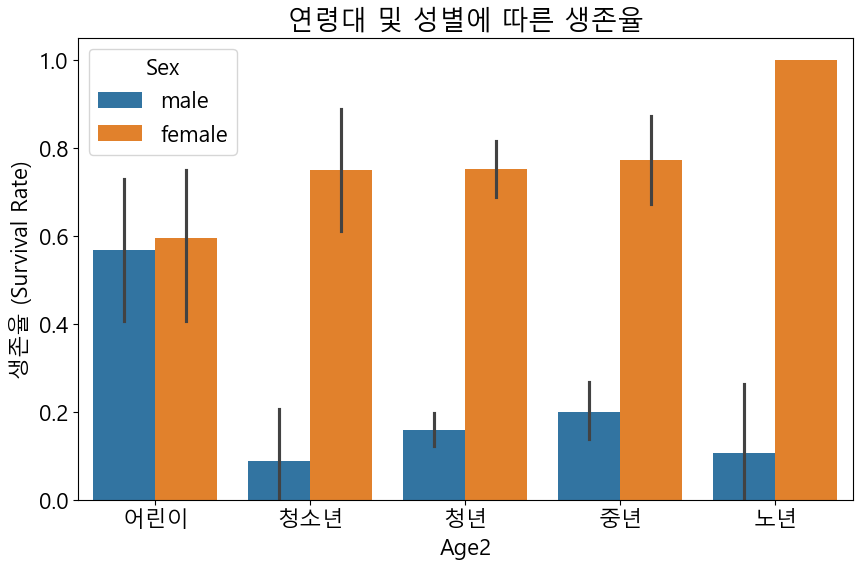

In [10]:
import seaborn as sns

lbl = ['어린이', '청소년', '청년', '중년', '노년']
df['Age2'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=lbl)
df['Age2']

plt.figure(figsize=(10, 6))
sns.barplot(x='Age2', y='Survived', hue='Sex', data=df)
plt.title('연령대 및 성별에 따른 생존율')
plt.ylabel('생존율 (Survival Rate)')
plt.show()


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Pclass', ylabel='Survived'>

Text(0.5, 1.0, '객실 등급 및 성별에 따른 생존율 추이')

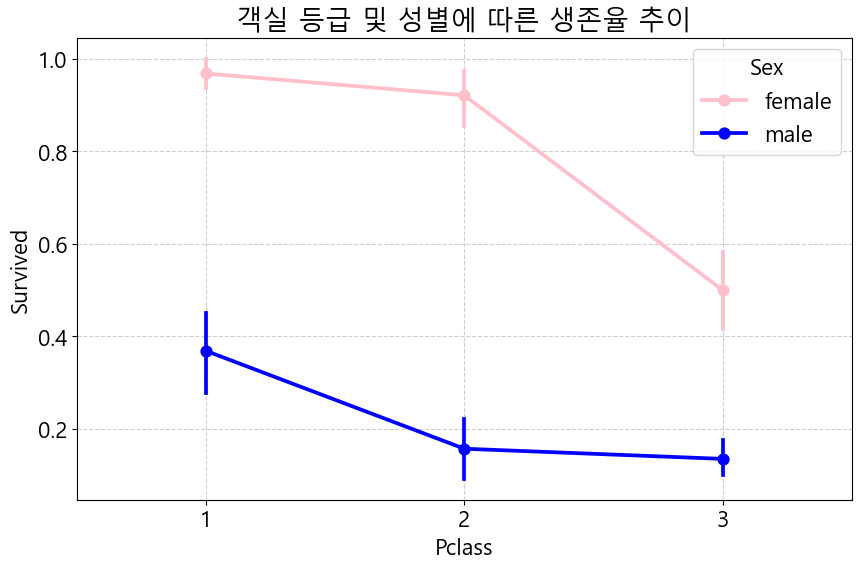

In [11]:
plt.figure(figsize=(10, 6))
sns.pointplot(x='Pclass', y='Survived', hue='Sex', data=df, palette={'male': 'blue', 'female': 'pink'})
plt.title('객실 등급 및 성별에 따른 생존율 추이')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

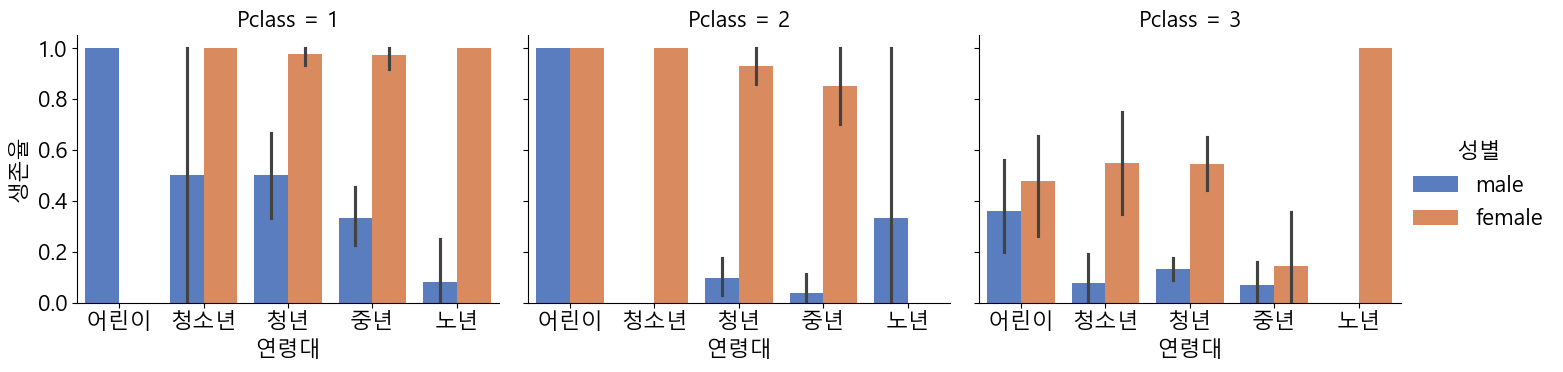

In [14]:
# 객실 등급(Pclass)별로 행을 나누어 연령대별 생존율 시각화
g = sns.FacetGrid(df, col='Pclass', height=4, aspect=1.2)
g.map(sns.barplot, 'Age2', 'Survived', 'Sex', palette='muted', order=lbl, hue_order=['male', 'female'])
g.add_legend(title='성별')
g.set_axis_labels("연령대", "생존율")
plt.show()

#### 5️⃣ Streamlit을 이용하여 대시보드로 제작
- 위에서 생존율 분석을 streamlit을 이용하여 대시보드로 제작하라
- .py 파일에 저장하여 터미널에서 실행한 결과로 웹브라우져에서 확인한다
- 설치 모듈 : 웹기반의 시각화로 plotly, 대시보드 streamlit 설치
- 주의점 : 나의 폴더 위치로 수정 필요, 컬럼명 일치여부 확인

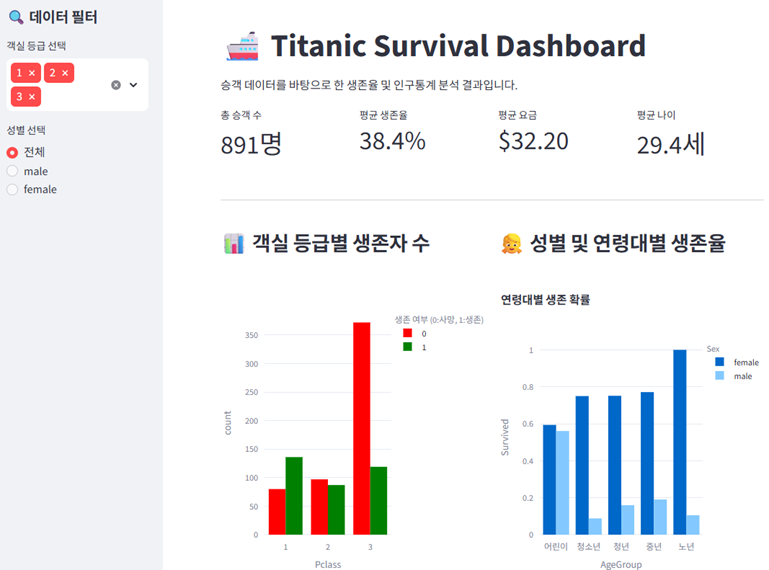

In [ ]:
# gemini를 이용한 코드 

import streamlit as st
import pandas as pd
import plotly.express as px
import seaborn as sns

# 페이지 설정
st.set_page_config(page_title="타이타닉 생존 분석 대시보드", layout="wide")

# 1. 데이터 로드 및 전처리 (캐싱을 통해 속도 향상)
@st.cache_data
def load_data():
    df = pd.read_csv('titanic.csv')
    # 호칭 추출 및 나이 결측치 채우기 (가장 효율적인 방법 적용)
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    # 항구 결측치 채우기
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    # 연령대 생성
    bins = [0, 12, 18, 35, 60, 100]
    labels = ['어린이', '청소년', '청년', '중년', '노년']
    df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
    return df

df = load_data()

# --- 사이드바: 필터 설정 ---
st.sidebar.header("🔍 데이터 필터")
selected_pclass = st.sidebar.multiselect("객실 등급 선택", options=[1, 2, 3], default=[1, 2, 3])
selected_sex = st.sidebar.radio("성별 선택", options=['전체', 'male', 'female'])

# 필터링 적용
filtered_df = df[df['Pclass'].isin(selected_pclass)]
if selected_sex != '전체':
    filtered_df = filtered_df[filtered_df['Sex'] == selected_sex]

# --- 메인 화면: 대시보드 구성 ---
st.title("🚢 Titanic Survival Dashboard")
st.markdown("승객 데이터를 바탕으로 한 생존율 및 인구통계 분석 결과입니다.")

# 2. 상단 KPI 카드 (핵심 지표)
col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric("총 승객 수", f"{len(filtered_df)}명")
with col2:
    survival_rate = filtered_df['Survived'].mean() * 100
    st.metric("평균 생존율", f"{survival_rate:.1f}%")
with col3:
    st.metric("평균 요금", f"${filtered_df['Fare'].mean():.2f}")
with col4:
    st.metric("평균 나이", f"{filtered_df['Age'].mean():.1f}세")

st.divider()

# 3. 차트 섹션
row1_col1, row1_col2 = st.columns(2)

with row1_col1:
    st.subheader("📊 객실 등급별 생존자 수")
    fig1 = px.histogram(filtered_df, x="Pclass", color="Survived", 
                        barmode="group", color_discrete_map={0: "red", 1: "green"},
                        labels={'Survived': '생존 여부 (0:사망, 1:생존)'})
    st.plotly_chart(fig1, use_container_width=True)

with row1_col2:
    st.subheader("👧 성별 및 연령대별 생존율")
    # 생존율 계산을 위한 집계
    survival_by_age = filtered_df.groupby(['AgeGroup', 'Sex'], as_index=False)['Survived'].mean()
    fig2 = px.bar(survival_by_age, x="AgeGroup", y="Survived", color="Sex",
                  barmode="group", title="연령대별 생존 확률")
    st.plotly_chart(fig2, use_container_width=True)

row2_col1, row2_col2 = st.columns(2)

with row2_col1:
    st.subheader("💰 요금(Fare)과 생존의 관계")
    fig3 = px.box(filtered_df, x="Survived", y="Fare", color="Survived",
                  points="all", title="생존 여부에 따른 요금 분포")
    st.plotly_chart(fig3, use_container_width=True)

with row2_col2:
    st.subheader("📍 탑승 항구별 승객 분포")
    embarked_counts = filtered_df['Embarked'].value_counts().reset_index()
    fig4 = px.pie(embarked_counts, values='count', names='Embarked', hole=0.4)
    st.plotly_chart(fig4, use_container_width=True)

# 4. 데이터 테이블 확인
if st.checkbox("전체 데이터 보기"):
    st.dataframe(filtered_df)

#### 6️⃣ streamlit에서 제공하는 웹서버에 배포
- github에 가입하여 필요 파일들을 업로드한 후 streamlit Cloud에 깃허브와 연결하면 배포 완료이다
1. requirements.txt 파일 만들기 : 실행에 필요한 모듈 목록 파일    
    plotly   
    pandas   
    streamlit   


2. githyb.com 에서 신규 회원가입하고 
    - 새로운 저장소(New Repository) 만들어 app.py,  requirements.txt, titanic.csv 파일 업로드

3. streamlit Cloud와 연결
    - github 계정으로 로그인 / create app / Deploy a public app from GitHub 으로 
    - Repository: 내아이디/titanic-dashboard 선택
    - Main file path: app.py 입력 
    - Deploy 클릭 : 몇분 소요 

    https://github.com/monoi999/titanic_dash.git    